In [1]:
from IPython.display import Markdown, display
display(Markdown("""# Quantum Machine Learning for Lithium-Ion Battery Materials Discovery

**Presentation notebook**

Goal: identify lithium-ion battery material candidates using Materials Project
data, XGBoost, India-focused screening, and a first QML baseline.
"""))

# Quantum Machine Learning for Lithium-Ion Battery Materials Discovery

**Presentation notebook**

Goal: identify lithium-ion battery material candidates using Materials Project
data, XGBoost, India-focused screening, and a first QML baseline.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

project_folder = Path.cwd()
processed_folder = project_folder / "data" / "processed"

lithium_scored_dataframe = pd.read_csv(processed_folder / "lithium india scored.csv")
final_shortlist_dataframe = pd.read_csv(processed_folder / "final india battery shortlist.csv")
qml_ready_dataframe = pd.read_csv(processed_folder / "qml_ready_lithium_india.csv")
qml_predictions_dataframe = pd.read_csv(processed_folder / "qml baseline predictions.csv")

dataset_summary = pd.DataFrame([
    {"dataset": "Lithium India scored", "rows": len(lithium_scored_dataframe), "columns": len(lithium_scored_dataframe.columns)},
    {"dataset": "Final India shortlist", "rows": len(final_shortlist_dataframe), "columns": len(final_shortlist_dataframe.columns)},
    {"dataset": "QML-ready dataset", "rows": len(qml_ready_dataframe), "columns": len(qml_ready_dataframe.columns)},
    {"dataset": "QML test predictions", "rows": len(qml_predictions_dataframe), "columns": len(qml_predictions_dataframe.columns)},
])
display(dataset_summary)

dataset,rows,columns
Lithium India scored,24957,37
Final India shortlist,629,21
QML-ready dataset,1000,27
QML test predictions,200,11


stage,rows
Raw MP snapshot,210579
Lithium dataset,24957
QML-ready dataset,1000
Final shortlist,629


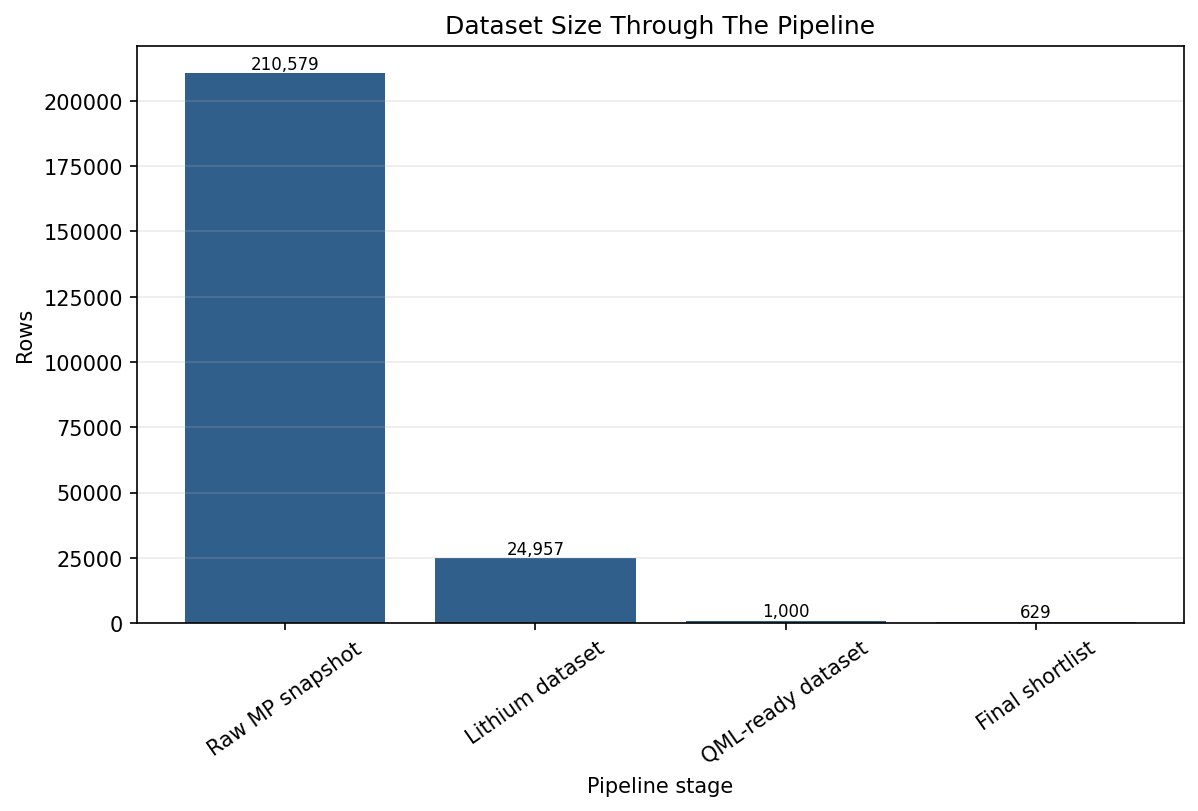

In [3]:
pipeline_counts_dataframe = pd.DataFrame([
    {"stage": "Raw MP snapshot", "rows": 210579},
    {"stage": "Lithium dataset", "rows": len(lithium_scored_dataframe)},
    {"stage": "QML-ready dataset", "rows": len(qml_ready_dataframe)},
    {"stage": "Final shortlist", "rows": len(final_shortlist_dataframe)},
])

plt.figure(figsize=(9, 5))
plt.bar(pipeline_counts_dataframe["stage"], pipeline_counts_dataframe["rows"])
plt.title("Dataset Size Through The Pipeline")
plt.xlabel("Pipeline stage")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

battery_family,rows
Other lithium material,14027
LCO-family,3541
LMO-family,3394
LTO-family,964
Li-S or sulfide-family,892
Silicon-family,852
LFP-family,735
Carbon-family,477


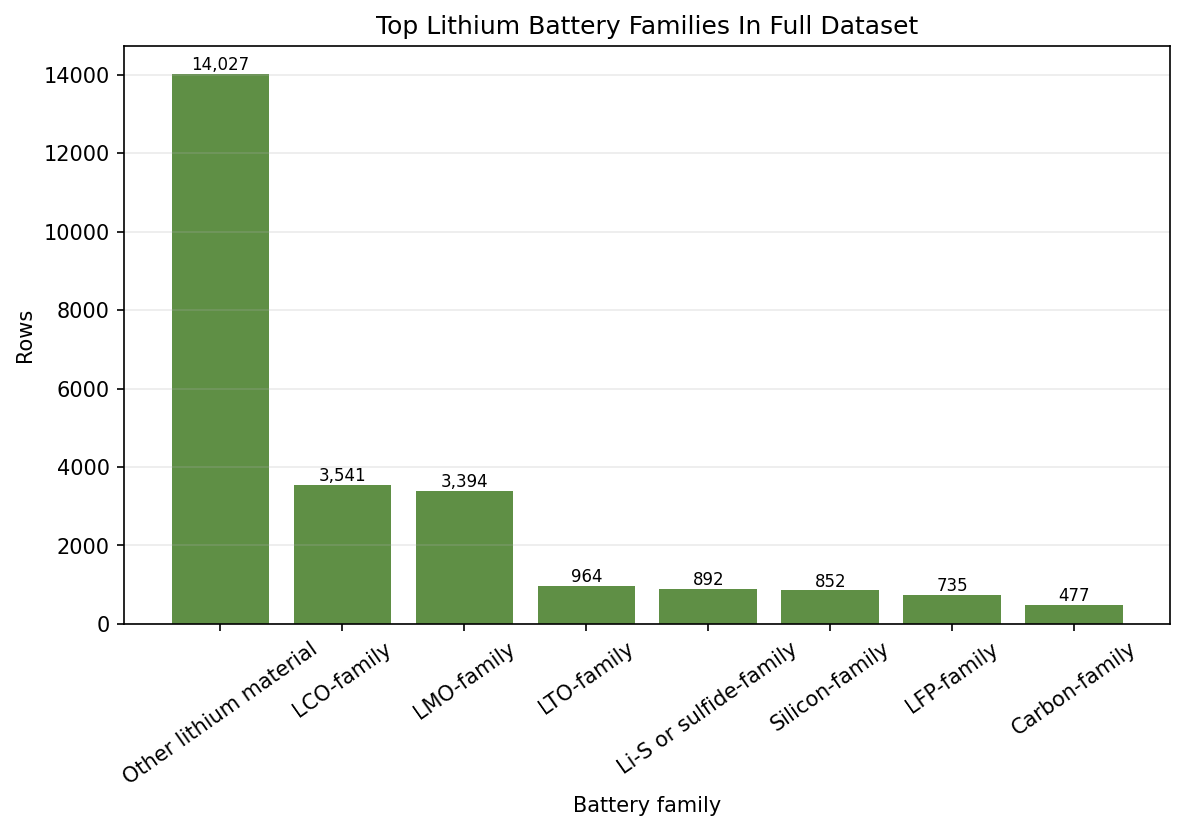

In [4]:
family_counts_dataframe = (
    lithium_scored_dataframe["battery_family"]
    .value_counts()
    .head(8)
    .reset_index()
)
family_counts_dataframe.columns = ["battery_family", "rows"]

display(family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(family_counts_dataframe["battery_family"], family_counts_dataframe["rows"])
plt.title("Top Lithium Battery Families In Full Dataset")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

india_decision_label,rows
Caution,13524
Research Candidate,5883
Avoid / Benchmark,4370
Recommend,1180


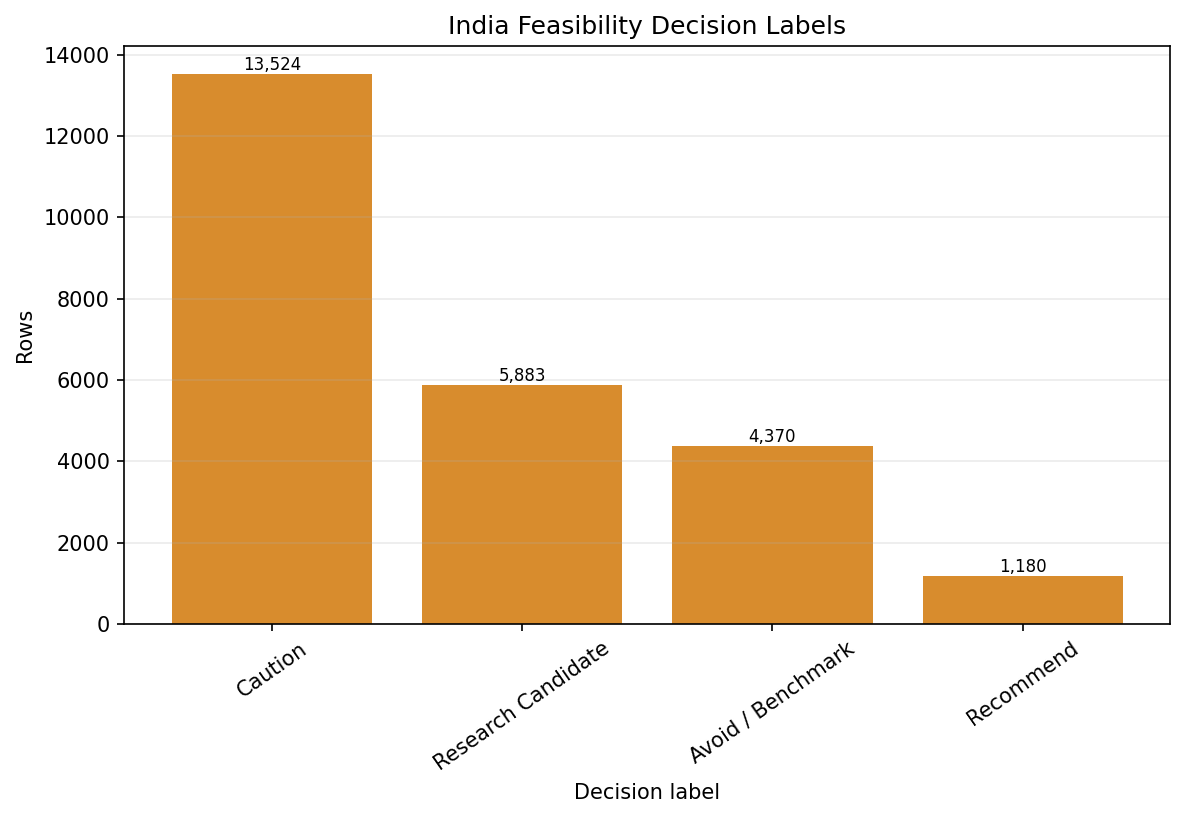

In [5]:
decision_counts_dataframe = (
    lithium_scored_dataframe["india_decision_label"]
    .value_counts()
    .reset_index()
)
decision_counts_dataframe.columns = ["india_decision_label", "rows"]

display(decision_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(decision_counts_dataframe["india_decision_label"], decision_counts_dataframe["rows"])
plt.title("India Feasibility Decision Labels")
plt.xlabel("Decision label")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

battery_family,rows
LFP-family,464
Li-S or sulfide-family,91
LMFP-family,48
Silicon-family,17
Carbon-family,5
LMO-family,4


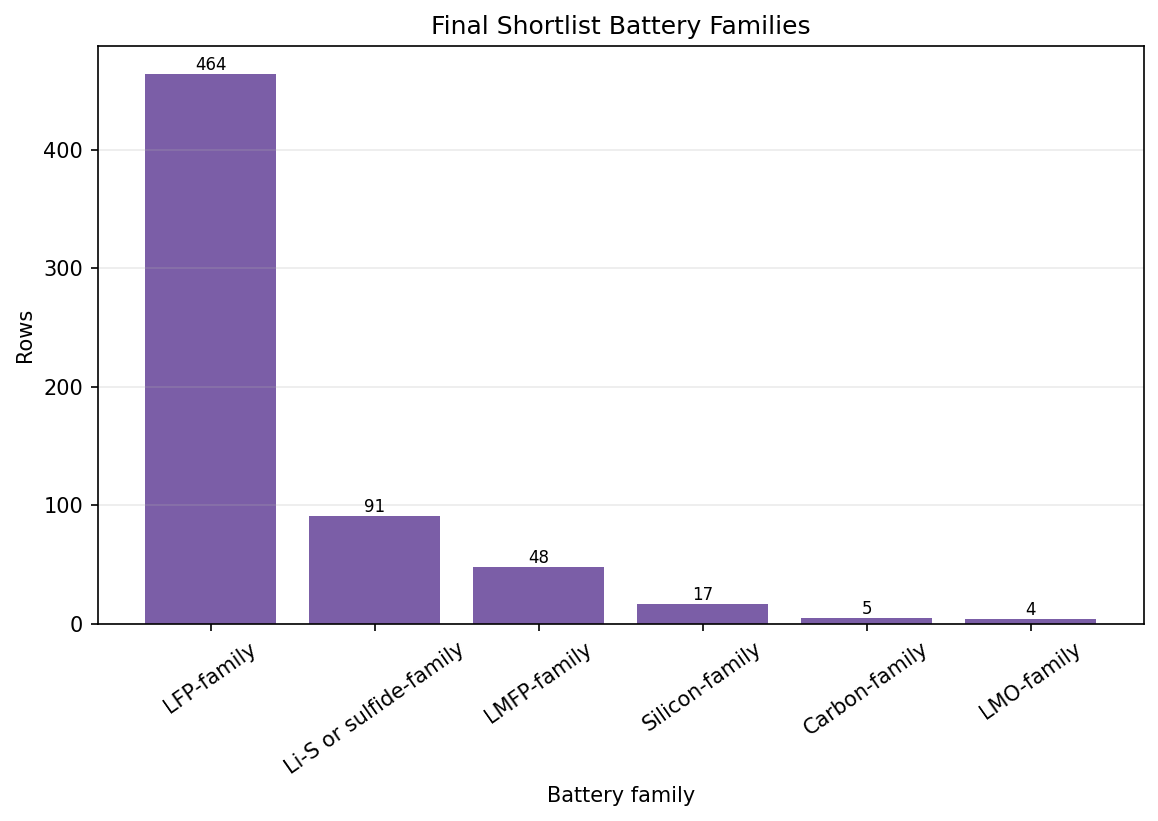

In [6]:
final_family_counts_dataframe = (
    final_shortlist_dataframe["battery_family"]
    .value_counts()
    .reset_index()
)
final_family_counts_dataframe.columns = ["battery_family", "rows"]

display(final_family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(final_family_counts_dataframe["battery_family"], final_family_counts_dataframe["rows"])
plt.title("Final Shortlist Battery Families")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

In [7]:
top_candidate_columns = [
    "material_id",
    "formula",
    "battery_family",
    "india_decision_label",
    "shortlist_rule_type",
    "shortlist_score",
    "predicted_stable_probability",
    "predicted_energy_above_hull_clipped",
    "india_feasibility_score",
]
top_candidates_dataframe = final_shortlist_dataframe[top_candidate_columns].head(10)
display(top_candidates_dataframe)

material_id,formula,battery_family,india_decision_label,shortlist_rule_type,shortlist_score,predicted_stable_probability,predicted_energy_above_hull_clipped,india_feasibility_score
mp-19430,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,59.52,0.167670,0.011649,98
mp-554093,Li9Fe3P8O29,LFP-family,Recommend,Benchmark family exception,59.10,0.147220,0.009104,98
mp-1195117,LiFeP2(HO3)2,LFP-family,Recommend,Benchmark family exception,57.42,0.172900,0.016302,94
mp-19294,LiFeP2O7,LFP-family,Recommend,Benchmark family exception,57.26,0.222164,0.038672,100
mp-19017,LiFePO4,LFP-family,Recommend,Benchmark family exception,56.48,0.138139,0.023703,100
mp-26985,Li2Fe3(P2O7)2,LFP-family,Recommend,Benchmark family exception,56.39,0.115441,0.015525,98
mp-1198378,NaLiFePO4F,LFP-family,Recommend,Benchmark family exception,56.22,0.167278,0.021042,94
mp-6373,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.50,0.131681,0.023631,98
mp-25993,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.32,0.126405,0.023346,98
mp-504179,LiFe(PO3)3,LFP-family,Recommend,Benchmark family exception,54.88,0.132133,0.026851,98


In [8]:
quantum_parameters_dataframe = pd.DataFrame([
    {"parameter": "QML model type", "value": "Simulated quantum kernel classifier"},
    {"parameter": "Number of qubits", "value": "10"},
    {"parameter": "Quantum state size", "value": "1024"},
    {"parameter": "Feature encoding", "value": "angle = pi * scaled_feature_value"},
    {"parameter": "Single-qubit state", "value": "[cos(angle / 2), sin(angle / 2)]"},
    {"parameter": "Kernel formula", "value": "K(x, y) = |<phi(x), phi(y)>|^2"},
    {"parameter": "Classifier", "value": "SVC with precomputed kernel"},
    {"parameter": "SVM C value", "value": "1.0"},
    {"parameter": "Train/test split", "value": "80/20"},
    {"parameter": "Random state", "value": "42"},
])
display(quantum_parameters_dataframe)

parameter,value
QML model type,Simulated quantum kernel classifier
Number of qubits,10
Quantum state size,1024
Feature encoding,angle = pi * scaled_feature_value
Single-qubit state,"[cos(angle / 2), sin(angle / 2)]"
Kernel formula,"K(x, y) = |<phi(x), phi(y)>|^2"
Classifier,SVC with precomputed kernel
SVM C value,1.0
Train/test split,80/20
Random state,42


model,accuracy,stable_precision,stable_recall,stable_f1
QML quantum kernel,0.8100,0.7870,0.85,0.8173
XGBoost same QML data,0.8300,0.8367,0.82,0.8283
XGBoost full project,0.9091,0.7300,0.70,0.7100


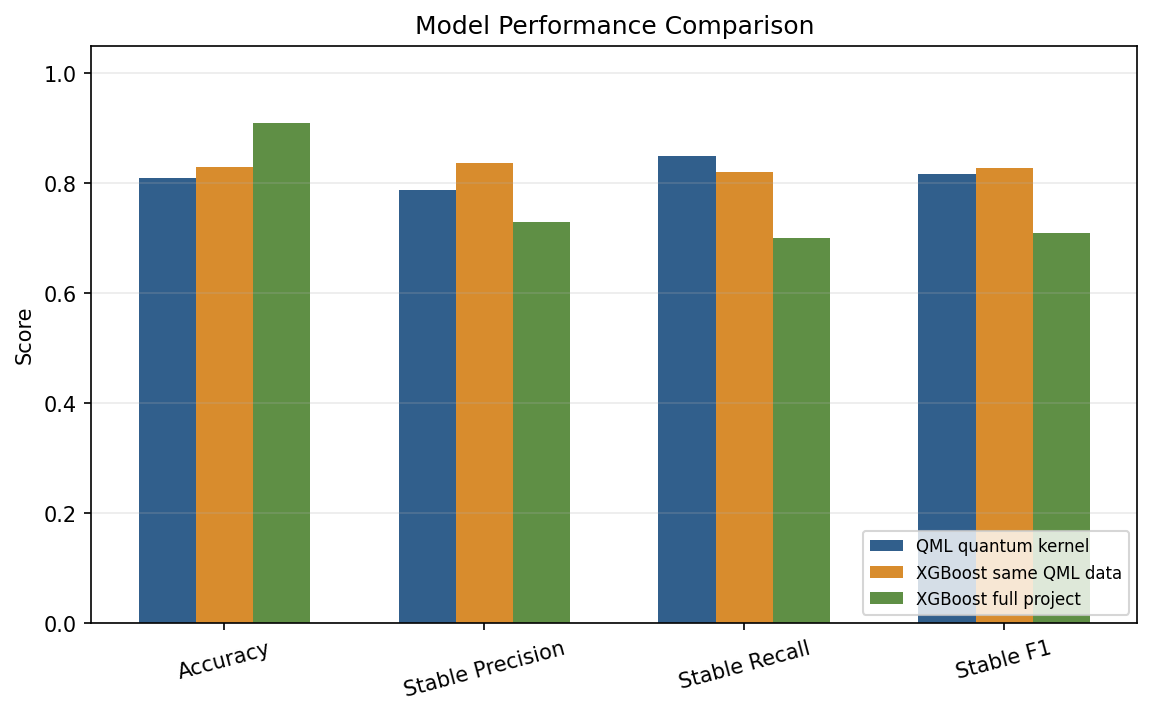

In [9]:
true_labels = qml_predictions_dataframe["target_is_stable"]
qml_predicted_labels = qml_predictions_dataframe["qml_predicted_label"]
xgboost_predicted_labels = qml_predictions_dataframe["xgboost_same_data_predicted_label"]

metric_dataframe = pd.DataFrame([
    {
        "model": "QML quantum kernel",
        "accuracy": accuracy_score(true_labels, qml_predicted_labels),
        "stable_precision": precision_score(true_labels, qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(true_labels, qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(true_labels, qml_predicted_labels, zero_division=0),
    },
    {
        "model": "XGBoost same QML data",
        "accuracy": accuracy_score(true_labels, xgboost_predicted_labels),
        "stable_precision": precision_score(true_labels, xgboost_predicted_labels, zero_division=0),
        "stable_recall": recall_score(true_labels, xgboost_predicted_labels, zero_division=0),
        "stable_f1": f1_score(true_labels, xgboost_predicted_labels, zero_division=0),
    },
    {
        "model": "XGBoost full project",
        "accuracy": 0.9091,
        "stable_precision": 0.7300,
        "stable_recall": 0.7000,
        "stable_f1": 0.7100,
    },
]).round(4)

display(metric_dataframe)

metric_dataframe.set_index("model")[["accuracy", "stable_precision", "stable_recall", "stable_f1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.show()

predicted_unstable,predicted_stable
77,23
15,85


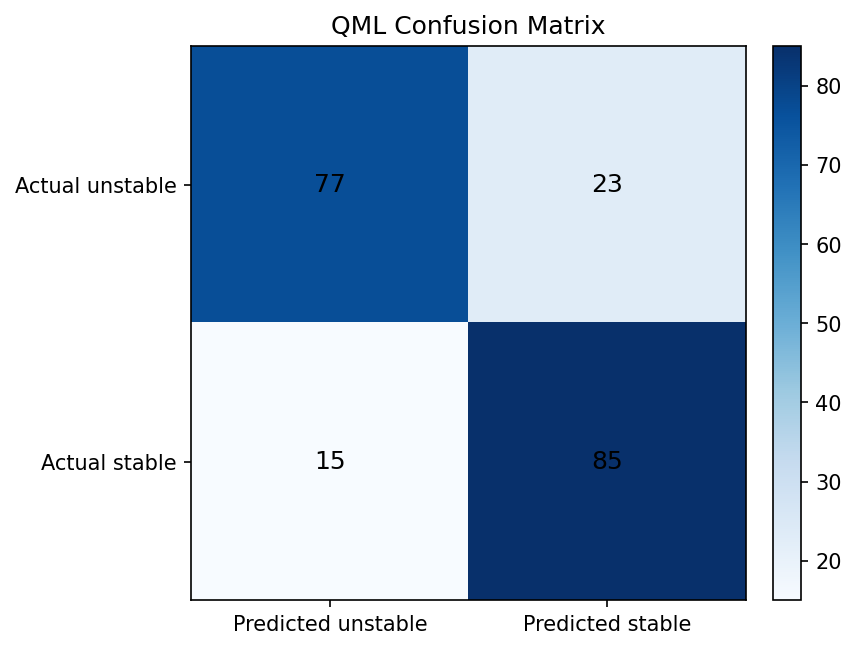

In [10]:
qml_confusion_matrix = confusion_matrix(true_labels, qml_predicted_labels, labels=[0, 1])
confusion_dataframe = pd.DataFrame(
    qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(qml_confusion_matrix, cmap="Blues")
plt.title("QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [11]:
sample_predictions_dataframe = qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "qml_predicted_label",
        "qml_stable_probability",
        "xgboost_same_data_predicted_label",
        "prediction_agreement",
    ]
].head(10)
display(sample_predictions_dataframe)

material_id,formula,target_is_stable,qml_predicted_label,qml_stable_probability,xgboost_same_data_predicted_label,prediction_agreement
mp-861915,LiDy2Ir,1,1,0.815821,1,True
mp-1191394,Li8Nd7Ge10,0,1,0.579917,1,True
mp-759724,Li3MnF7,0,0,0.161744,0,True
mp-37480,LiSbSe2,0,1,0.832171,1,True
mp-3203193,LiV(CuS2)2,1,1,0.770909,1,True
mp-3203521,BaSr2(LiSn2)4,1,1,0.723089,1,True
mp-1212343,Li22(Cu3Si2)7,1,1,0.823011,1,True
mp-1185354,LiGd2Os,1,1,0.814218,1,True
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.175468,0,True
mp-758945,Li5CuHO4,0,1,0.481264,0,False


In [12]:
display(Markdown("""# Presentation Conclusion

**What we achieved**

- Built a complete lithium battery material pipeline.
- Created India-focused material scoring and final shortlist.
- Trained XGBoost as the classical baseline.
- Prepared a balanced QML-ready dataset.
- Trained a first simulated quantum-kernel classifier.

**Main model result**

- QML accuracy on QML-ready test split: **0.8100**
- Same-data XGBoost accuracy: **0.8300**

**Next step**

Create final report visuals and try improved QML feature maps or smaller
feature sets.
"""))

# Presentation Conclusion

**What we achieved**

- Built a complete lithium battery material pipeline.
- Created India-focused material scoring and final shortlist.
- Trained XGBoost as the classical baseline.
- Prepared a balanced QML-ready dataset.
- Trained a first simulated quantum-kernel classifier.

**Main model result**

- QML accuracy on QML-ready test split: **0.8100**
- Same-data XGBoost accuracy: **0.8300**

**Next step**

Create final report visuals and try improved QML feature maps or smaller
feature sets.
